## Music Genre Classification

### Introduction

For accurate results, it is recommended to run this notebook from start to finish.

Several sections depend on variables, datasets, and preprocessing steps defined in earlier cells. Running individual cells in isolation can lead to:
- Inconsistent model performance
- Use of outdated or partially defined variables

To ensure reproducibility and correctness, execute all cells in order.

#### All neccessary imports for the following code:

In [25]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

# Task 1

Accuracy for k-NN (k=5) classifier: 0.3939393939393939
              precision    recall  f1-score   support

       blues       0.29      0.30      0.29        20
   classical       0.67      0.74      0.70        19
     country       0.28      0.26      0.27        19
       disco       0.33      0.55      0.42        20
      hiphop       0.50      0.55      0.52        20
        jazz       0.32      0.35      0.33        20
       metal       0.35      0.35      0.35        20
         pop       0.62      0.50      0.56        20
      reggae       0.50      0.30      0.38        20
        rock       0.08      0.05      0.06        20

    accuracy                           0.39       198
   macro avg       0.39      0.39      0.39       198
weighted avg       0.39      0.39      0.39       198



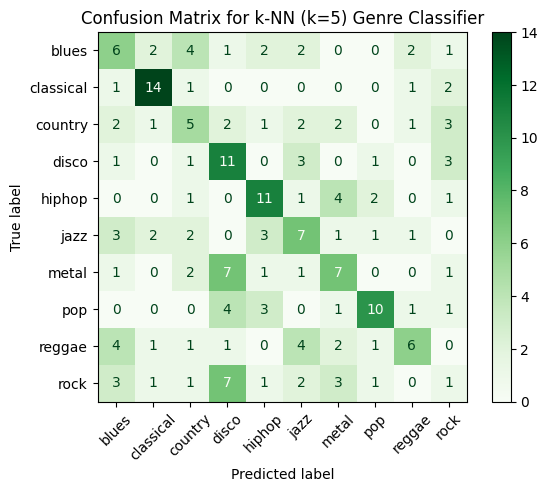

In [26]:
#Read in the data
dataset = pd.read_csv(r"music_files/GenreClassData_30s.txt", sep ="\t")

#Pick interested features and target
feature_columns = ["spectral_rolloff_mean","mfcc_1_mean","spectral_centroid_mean", "tempo"]
target_column = "Genre"

#Splitting training dataset and test dataset
train_dataset = dataset[dataset["Type"]=="Train"]
test_dataset = dataset[dataset["Type"]=="Test"]

#Splitting dataset further into features and targets
feature_train = train_dataset[feature_columns]
target_train = train_dataset[target_column]
feature_test = test_dataset[feature_columns]
target_test = test_dataset[target_column]

#Scale data to have fair distances for kNN
scaler = StandardScaler ()
feature_train = scaler.fit_transform(feature_train)
feature_test = scaler.transform(feature_test)

#Train model with 5-NN
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(feature_train,target_train)

#Predict and test the accuracy of prediction
target_predict = knn_classifier.predict(feature_test)
accuracy = accuracy_score(target_test, target_predict)
print (f"Accuracy for k-NN (k=5) classifier: {accuracy}")
print(classification_report(target_test, target_predict))

#Plotting confusion matrix
ConfusionMatrixDisplay.from_predictions(target_test, target_predict, xticks_rotation=45,cmap="Greens")
plt.title("Confusion Matrix for k-NN (k=5) Genre Classifier")
plt.show()

# Task 2

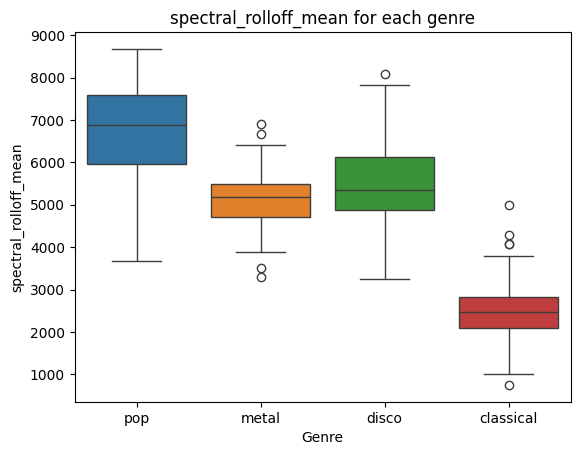

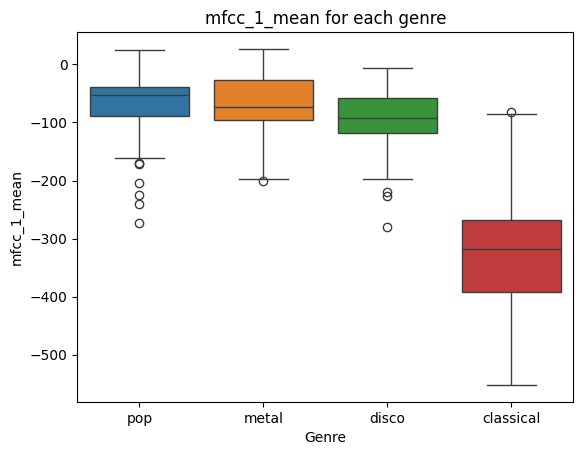

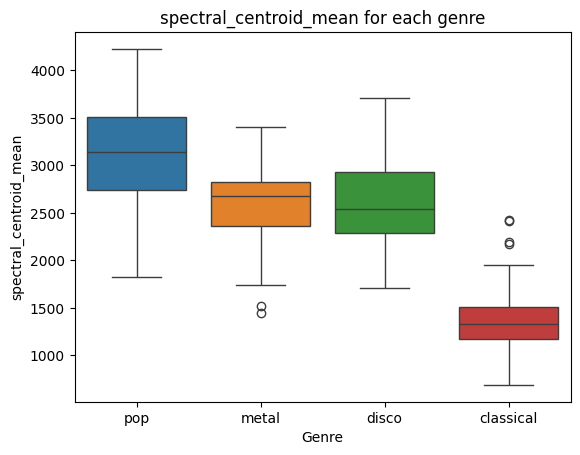

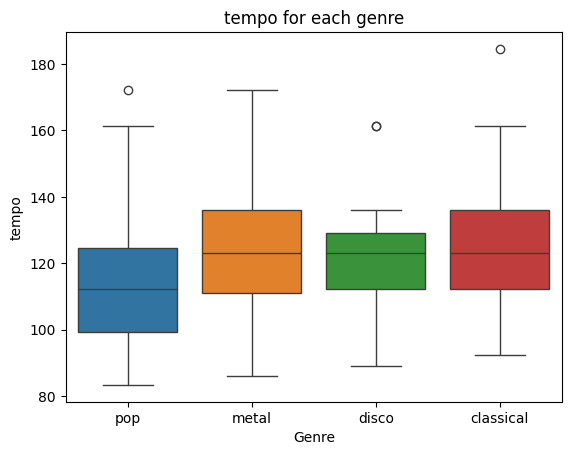

In [27]:
target_genres = ["pop", "disco", "metal", "classical"]
dataset_filtered = dataset[dataset["Genre"].isin(target_genres)].copy()

#Make boxplots for analyzing performace, for selected genres
for feature in feature_columns:
    sns.boxplot(
    data = dataset_filtered, x = "Genre",
    y = feature, hue = "Genre")

    plt.title(f"{feature} for each genre")
    plt.show()

# Task 3

Test accuracy for k-NN (k=5) classifier: 0.3686868686868687
              precision    recall  f1-score   support

       blues       0.17      0.25      0.20        20
   classical       0.71      0.79      0.75        19
     country       0.29      0.26      0.28        19
       disco       0.18      0.25      0.21        20
      hiphop       0.23      0.15      0.18        20
        jazz       0.32      0.40      0.36        20
       metal       0.54      0.70      0.61        20
         pop       0.67      0.60      0.63        20
      reggae       0.31      0.25      0.28        20
        rock       0.25      0.05      0.08        20

    accuracy                           0.37       198
   macro avg       0.37      0.37      0.36       198
weighted avg       0.37      0.37      0.36       198



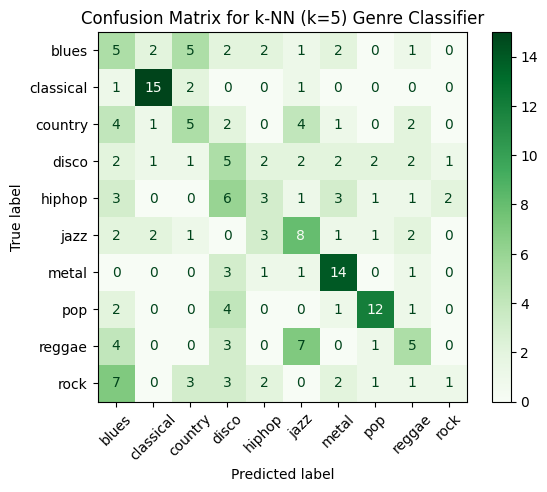

In [ ]:
feature_columns_without_tempo = ["spectral_rolloff_mean","mfcc_1_mean","spectral_centroid_mean"]

#Dataset with features without tempo
feature_train = train_dataset[feature_columns_without_tempo]
target_train = train_dataset[target_column]
feature_test = test_dataset[feature_columns_without_tempo]
target_test = test_dataset[target_column]

#Scale data to have fair distances for kNN
scaler = StandardScaler ()
feature_train = scaler.fit_transform(feature_train)
feature_test = scaler.transform(feature_test)

#Train model with k-NN (k=5)
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(feature_train,target_train)

#Predict and test the accuracy of prediction
target_predict = knn_classifier.predict(feature_test)
accuracy = accuracy_score(target_test, target_predict)
print (f"Accuracy for k-NN (k=5) classifier: {accuracy}")
print(classification_report(target_test, target_predict))

#Plotting confusion matrix
ConfusionMatrixDisplay.from_predictions(target_test, target_predict, xticks_rotation=45,cmap="Greens")
plt.title("Confusion Matrix for k-NN (k=5) Genre Classifier")
plt.show()

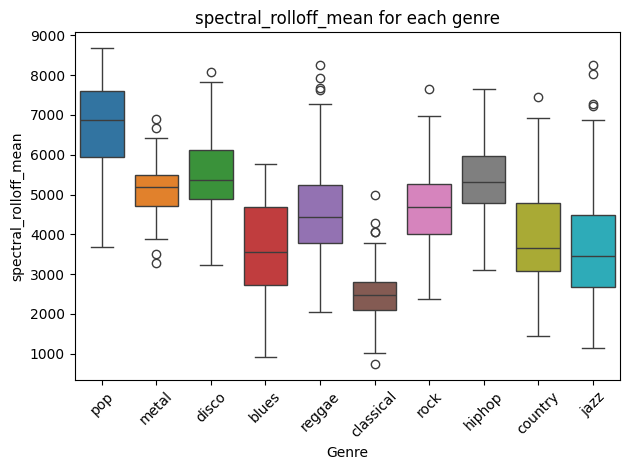

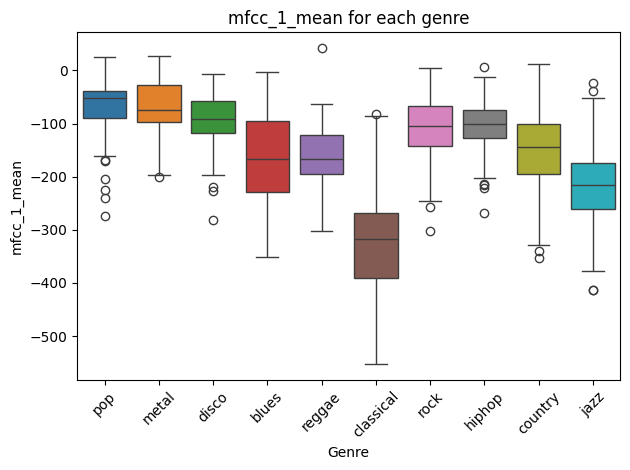

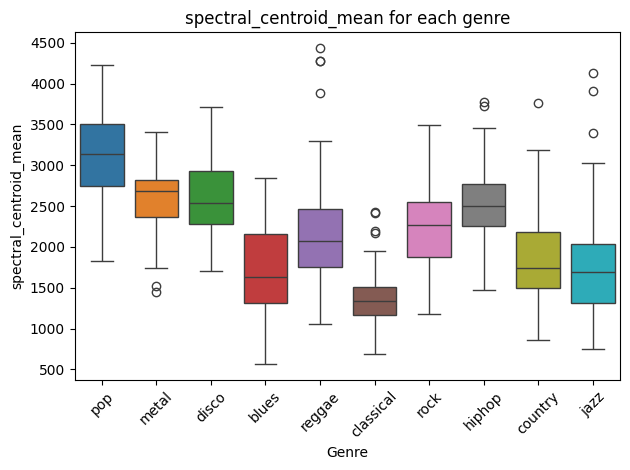

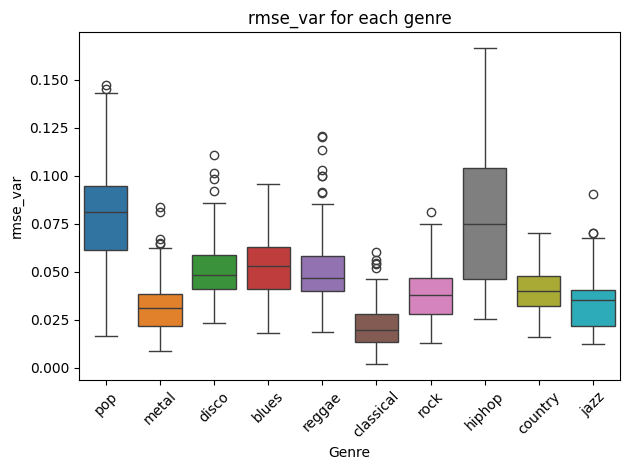

In [29]:
all_features = dataset.select_dtypes(include="number").columns
feature_columns_new = ["spectral_rolloff_mean","mfcc_1_mean","spectral_centroid_mean", "rmse_var"]

#Make boxplots for analyzing performace, for all genres
for feature in feature_columns_new:
    sns.boxplot(
    data = dataset, x = "Genre",
    y = feature, hue = "Genre")

    plt.title(f"{feature} for each genre")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Test accuracy for k-NN (k=5) classifier: 0.48484848484848486
              precision    recall  f1-score   support

       blues       0.39      0.70      0.50        20
   classical       0.71      0.79      0.75        19
     country       0.20      0.16      0.18        19
       disco       0.28      0.35      0.31        20
      hiphop       0.48      0.60      0.53        20
        jazz       0.47      0.35      0.40        20
       metal       0.80      0.80      0.80        20
         pop       0.64      0.45      0.53        20
      reggae       0.59      0.50      0.54        20
        rock       0.30      0.15      0.20        20

    accuracy                           0.48       198
   macro avg       0.49      0.48      0.47       198
weighted avg       0.49      0.48      0.47       198



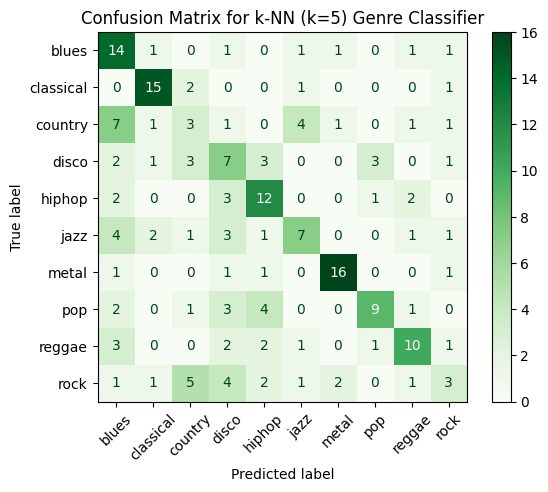

In [ ]:
feature_columns_new = ["spectral_rolloff_mean","mfcc_1_mean","spectral_centroid_mean", "rmse_var"]

#Dataset with features including rmse_var
feature_train = train_dataset[feature_columns_new]
target_train = train_dataset[target_column]
feature_test = test_dataset[feature_columns_new]
target_test = test_dataset[target_column]

#Scale data to have fair distances for kNN
scaler = StandardScaler ()
feature_train = scaler.fit_transform(feature_train)
feature_test = scaler.transform(feature_test)

#Train model with k-NN (k=5)
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(feature_train,target_train)

#Predict and test the accuracy of prediction
target_predict = knn_classifier.predict(feature_test)
accuracy = accuracy_score(target_test, target_predict)
print (f"Accuracy for k-NN (k=5) classifier: {accuracy}")
print(classification_report(target_test, target_predict))

#Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(target_test, target_predict, xticks_rotation=45,cmap="Greens")
plt.title("Confusion Matrix for k-NN (k=5) Genre Classifier")
plt.show()

# Task 4

Test accuracy for k-NN classifier: 0.6868686868686869
              precision    recall  f1-score   support

       blues       0.75      0.60      0.67        20
   classical       0.90      0.95      0.92        19
     country       0.50      0.84      0.63        19
       disco       0.46      0.55      0.50        20
      hiphop       0.63      0.85      0.72        20
        jazz       0.87      0.65      0.74        20
       metal       0.85      0.85      0.85        20
         pop       0.82      0.70      0.76        20
      reggae       0.80      0.60      0.69        20
        rock       0.50      0.30      0.38        20

    accuracy                           0.69       198
   macro avg       0.71      0.69      0.69       198
weighted avg       0.71      0.69      0.68       198



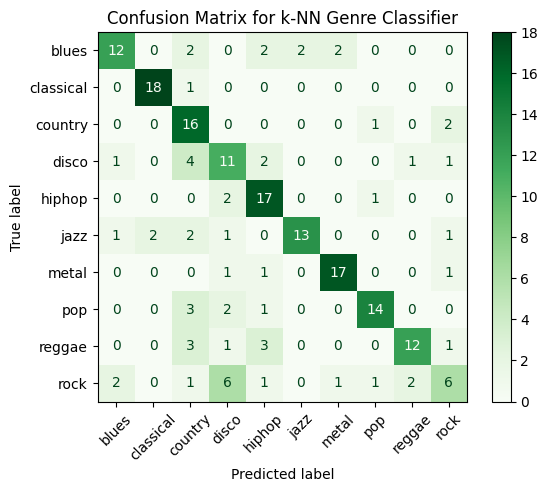

In [34]:
#Read inn all datasets
dataset_5 = pd.read_csv(r"music_files/GenreClassData_5s.txt", sep ="\t")
dataset_10 = pd.read_csv(r"music_files/GenreClassData_10s.txt", sep ="\t")
dataset_30 = pd.read_csv(r"music_files/GenreClassData_30s.txt", sep ="\t")

#Combine all datasets
dataset = pd.concat([dataset_5, dataset_10, dataset_30], ignore_index=True)

#Exclude the columns we are not interested in
exclude_columns = ["Track ID", "File", "GenreID", "Genre", "Type", "SegmentLength"]
feature_columns = []
for column in dataset.columns:
    if column not in exclude_columns:
        feature_columns.append(column)

#Splitting training dataset and test dataset
train_dataset = dataset[dataset["Type"] == "Train"]
test_dataset = dataset[dataset["Type"] == "Test"]

#Splitting dataset further into features and targets
feature_train = train_dataset[feature_columns]
target_train = train_dataset["Genre"]
feature_test = test_dataset[feature_columns]
target_test = test_dataset["Genre"]

#Scale data to have fair distances for kNN
scaler = StandardScaler ()
feature_train = scaler.fit_transform(feature_train)
feature_test = scaler.transform(feature_test)

#Train model with kNN
knn_classifier = KNeighborsClassifier (n_neighbors = 5)
knn_classifier.fit(feature_train,target_train)

#Majority voting per series
def most_commom_decision(series):
    return series.value_counts().idxmax()

#Predict and test the accuracy of prediction
test_dataset["kNNPredict"] = knn_classifier.predict(feature_test)
target_predict = test_dataset.groupby("Track ID")["kNNPredict"].apply(most_commom_decision)
target_test = test_dataset.groupby("Track ID")["Genre"].first().reindex(target_predict.index)

accuracy = accuracy_score(target_test, target_predict)
print (f"Test accuracy for k-NN classifier: {accuracy}")
print(classification_report(target_test, target_predict))

#Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(target_test, target_predict, xticks_rotation=45,cmap="Greens")
plt.title("Confusion Matrix for k-NN Genre Classifier")
plt.show()

Accuracy for RFC: 0.7676767676767676
              precision    recall  f1-score   support

       blues       0.86      0.90      0.88        20
   classical       0.85      0.89      0.87        19
     country       0.70      0.74      0.72        19
       disco       0.56      0.50      0.53        20
      hiphop       0.84      0.80      0.82        20
        jazz       0.80      0.80      0.80        20
       metal       0.87      1.00      0.93        20
         pop       0.73      0.80      0.76        20
      reggae       0.85      0.85      0.85        20
        rock       0.53      0.40      0.46        20

    accuracy                           0.77       198
   macro avg       0.76      0.77      0.76       198
weighted avg       0.76      0.77      0.76       198



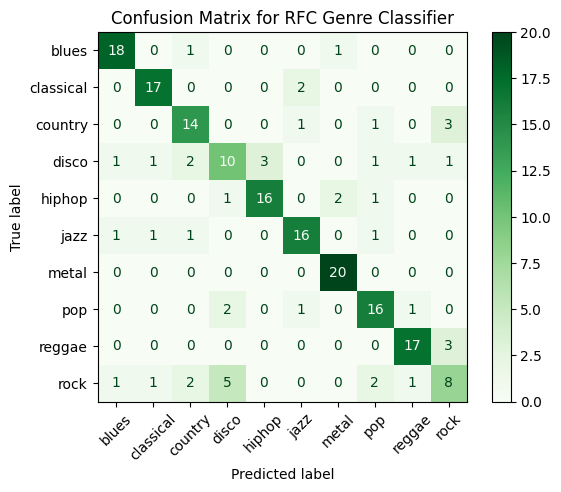

In [35]:
#Train random forest classifier, with 300 decision trees
random_forest = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
random_forest.fit(feature_train, target_train)

#Majority voting per series
def most_commom_decision(series):
    return series.value_counts().idxmax()

#Predict and test the accuracy
test_dataset["ForestPredict"] = random_forest.predict(feature_test)
target_predict = test_dataset.groupby("Track ID")["ForestPredict"].apply(most_commom_decision)
target_test = test_dataset.groupby("Track ID")["Genre"].first().reindex(target_predict.index)

accuracy = accuracy_score(target_test, target_predict)
print(f"Accuracy for RFC: {accuracy}")
print(classification_report(target_test, target_predict))

#Plot confusion matrix
ConfusionMatrixDisplay.from_predictions (target_test, target_predict, xticks_rotation=45, cmap="Greens")
plt.title("Confusion Matrix for RFC Genre Classifier")
plt.show()

Accuracy for XGBoost: 0.7676767676767676
              precision    recall  f1-score   support

       blues       0.76      0.80      0.78        20
   classical       0.89      0.89      0.89        19
     country       0.65      0.79      0.71        19
       disco       0.57      0.60      0.59        20
      hiphop       0.81      0.85      0.83        20
        jazz       0.94      0.80      0.86        20
       metal       0.91      1.00      0.95        20
         pop       0.78      0.70      0.74        20
      reggae       0.81      0.85      0.83        20
        rock       0.53      0.40      0.46        20

    accuracy                           0.77       198
   macro avg       0.77      0.77      0.76       198
weighted avg       0.77      0.77      0.76       198



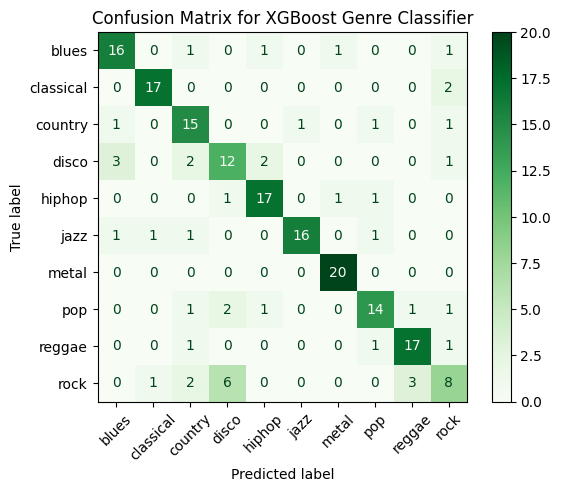

In [36]:
#Encode target labels, as XGBoost expects class labels as numbers
label_encoder = LabelEncoder()
target_train_encoded = label_encoder.fit_transform(target_train)

#Train XGBoost classifier, with 300 decision trees
xgb_classifier = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42,
    n_jobs=-1)
xgb_classifier.fit(feature_train, target_train_encoded)

#Majority voting per series
def most_common_decision(series):
    return series.value_counts().idxmax()

#Predict and test the accuracy
xgb_predictions_encoded = xgb_classifier.predict(feature_test)
xgb_predictions = label_encoder.inverse_transform(xgb_predictions_encoded)

test_dataset["XGBPrediction"] = xgb_predictions
target_predict = test_dataset.groupby("Track ID")["XGBPrediction"].apply(most_common_decision)
target_test = test_dataset.groupby("Track ID")["Genre"].first().reindex(target_predict.index)

accuracy = accuracy_score(target_test, target_predict)
print(f"Accuracy for XGBoost: {accuracy}")
print(classification_report(target_test, target_predict))

#Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(target_test, target_predict, xticks_rotation=45, cmap="Greens")
plt.title("Confusion Matrix for XGBoost Genre Classifier")
plt.show()